<a href="https://colab.research.google.com/github/sthones/Bolao2026-DIRCO/blob/main/bolao2026-DIRCO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 52.3 MB/s eta 0:00:00


In [4]:
pip install pandas


In [5]:
pip install numpy

In [6]:
pip install itertools


ERROR: Could not find a version that satisfies the requirement itertools (from versions: none)
ERROR: No matching distribution found for itertools


In [7]:
pip install io


ERROR: Could not find a version that satisfies the requirement io (from versions: none)
ERROR: No matching distribution found for io


In [8]:
pip install matplotlib


In [9]:
pip install pyplot


ERROR: Could not find a version that satisfies the requirement pyplot (from versions: none)
ERROR: No matching distribution found for pyplot


In [10]:
pip install seaborn

2026-06-01 20:52:07.361 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 20:52:07.366 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-06-01 20:52:07.376 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-06-01 20:52:07.377 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 20:52:07.462 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-01 20:52:07.465 WARNING streamlit.runtime.state.session_state_proxy: Session state does not function when running a script without `streamlit run`
2026-06-01 20:52:07.469 

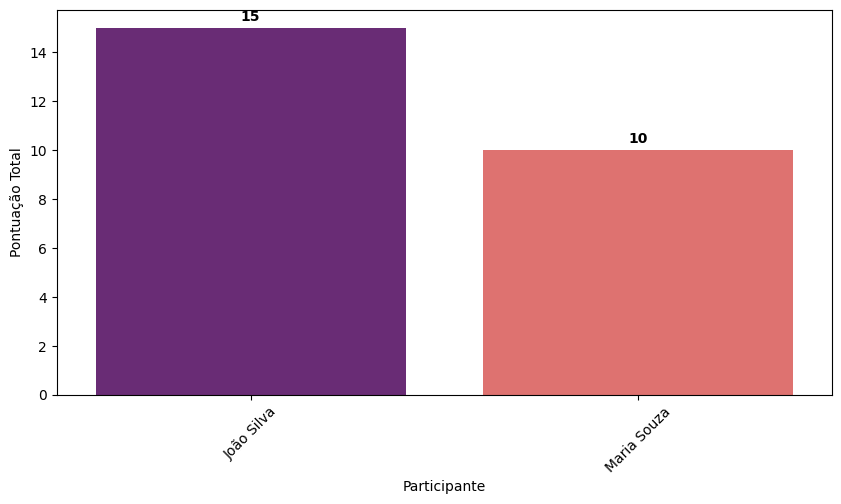

In [11]:
import streamlit as st
import pandas as pd
import numpy as np
import itertools
import io
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# CONFIGURAÇÃO INICIAL DA PÁGINA
# ==========================================
st.set_page_config(page_title="Bolão Copa 2026", page_icon="🏆", layout="wide")

# ==========================================
# 1. CARGA DE DADOS (Com Cache para otimização)
# ==========================================
@st.cache_data
def carregar_jogos():
    dados_copa = """Grupo,Time,Data_Estreia
A,México,11-Jun-26\nA,África do Sul,11-Jun-26\nA,Coreia do Sul,11-Jun-26\nA,República Tcheca,11-Jun-26
B,Canadá,12-Jun-26\nB,Bósnia,12-Jun-26\nB,Qatar,13-Jun-26\nB,Suíça,13-Jun-26
C,Brasil,13-Jun-26\nC,Marrocos,13-Jun-26\nC,Haiti,13-Jun-26\nC,Escócia,13-Jun-26
D,Estados Unidos,12-Jun-26\nD,Paraguai,12-Jun-26\nD,Austrália,13-Jun-26\nD,Turquia,13-Jun-26
E,Alemanha,14-Jun-26\nE,Curaçao,14-Jun-26\nE,Costa do Marfim,14-Jun-26\nE,Equador,14-Jun-26
F,Holanda,14-Jun-26\nF,Japão,14-Jun-26\nF,Suécia,14-Jun-26\nF,Tunísia,14-Jun-26
G,Bélgica,15-Jun-26\nG,Costa Rica,15-Jun-26\nG,Irã,15-Jun-26\nG,Uruguai,15-Jun-26
H,Espanha,15-Jun-26\nH,Arábia Saudita,15-Jun-26\nH,Gâmbia,15-Jun-26\nH,Eslovênia,15-Jun-26
I,França,16-Jun-26\nI,Senegal,16-Jun-26\nI,Noruega,16-Jun-26\nI,Bolívia,16-Jun-26
J,Argentina,16-Jun-26\nJ,Argélia,16-Jun-26\nJ,Áustria,16-Jun-26\nJ,Jordânia,16-Jun-26
K,Portugal,17-Jun-26\nK,RD Congo,17-Jun-26\nK,Uzbequistão,17-Jun-26\nK,Colômbia,17-Jun-26
L,Inglaterra,17-Jun-26\nL,Croácia,17-Jun-26\nL,Gana,17-Jun-26\nL,Panamá,17-Jun-26"""

    df_selecoes = pd.read_csv(io.StringIO(dados_copa))
    world_cup_games = []
    game_count = 1

    for grupo, df_grupo in df_selecoes.groupby('Grupo'):
        lista_times = df_grupo['Time'].tolist()
        confrontos = list(itertools.combinations(lista_times, 2))

        for team_a, team_b in confrontos:
            world_cup_games.append({
                "game_id": f"WC26_G{game_count:03d}",
                "group": grupo,
                "team_a": team_a,
                "team_b": team_b,
                "real_a": np.nan,
                "real_b": np.nan
            })
            game_count += 1

    df = pd.DataFrame(world_cup_games)

    # --- RESULTADOS REAIS SIMULADOS (Atualize aqui durante a Copa) ---
    df.loc[df['game_id'] == 'WC26_G001', ['real_a', 'real_b']] = [2, 1]
    df.loc[df['game_id'] == 'WC26_G002', ['real_a', 'real_b']] = [1, 1]
    df.loc[df['game_id'] == 'WC26_G003', ['real_a', 'real_b']] = [0, 3]

    return df

df_resultados = carregar_jogos()

# ==========================================
# 2. SISTEMA DE PONTUAÇÃO
# ==========================================
def calculate_score(row):
    pred_a, pred_b = row['pred_a'], row['pred_b']
    real_a, real_b = row['real_a'], row['real_b']

    if pd.isna(real_a) or pd.isna(real_b): return 0

    real_win, real_draw, real_loss = real_a > real_b, real_a == real_b, real_a < real_b
    pred_win, pred_draw, pred_loss = pred_a > pred_b, pred_a == pred_b, pred_a < pred_b

    if pred_a == real_a and pred_b == real_b: return 10
    if real_draw and pred_draw: return 5

    if (real_win and pred_win) or (real_loss and pred_loss):
        if (real_win and pred_a == real_a) or (real_loss and pred_b == real_b): return 6
        if (real_win and pred_b == real_b) or (real_loss and pred_a == real_a): return 5
        return 4

    return 0

# ==========================================
# 3. BANCO DE DADOS EM MEMÓRIA (Session State)
# ==========================================
# Inicializa a base de palpites com alguns testes para o ranking não nascer vazio
if 'base_palpites' not in st.session_state:
    st.session_state.base_palpites = pd.DataFrame([
        {"participant_id": "P01", "name": "João Silva", "game_id": "WC26_G001", "pred_a": 2, "pred_b": 1},
        {"participant_id": "P01", "name": "João Silva", "game_id": "WC26_G002", "pred_a": 0, "pred_b": 0},
        {"participant_id": "P02", "name": "Maria Souza", "game_id": "WC26_G001", "pred_a": 3, "pred_b": 1},
        {"participant_id": "P02", "name": "Maria Souza", "game_id": "WC26_G003", "pred_a": 0, "pred_b": 2}
    ])

# ==========================================
# 4. INTERFACE DO STREAMLIT
# ==========================================
st.title("🏆 Bolão da Copa do Mundo 2026")

# Criação das abas de navegação
aba1, aba2, aba3 = st.tabs(["📝 Fazer Palpites", "📊 Ranking e Dashboard", "📜 Regras do Bolão"])

# --- ABA 1: FORMULÁRIO DE PALPITES ---
with aba1:
    st.header("Envie seus Palpites")

    with st.form("form_palpites"):
        nome_participante = st.text_input("Seu Nome Completo:", max_chars=50)
        email_participante = st.text_input("Seu E-mail:")

        st.subheader("Fase de Grupos")
        novos_palpites = []

        # Filtra apenas os 10 primeiros jogos para o formulário não ficar gigante no teste
        # Para a versão final, remova o .head(10) para exibir os 72 jogos
        jogos_exibicao = df_resultados.head(10)

        for index, row in jogos_exibicao.iterrows():
            st.write(f"**Grupo {row['group']}**")
            col1, col2, col3, col4, col5 = st.columns([2, 1, 0.5, 1, 2])

            with col1: st.markdown(f"<h5 style='text-align: right;'>{row['team_a']}</h5>", unsafe_allow_html=True)
            with col2: gols_a = st.number_input("", key=f"a_{row['game_id']}", step=1, min_value=0, label_visibility="collapsed")
            with col3: st.markdown("<h5 style='text-align: center;'>X</h5>", unsafe_allow_html=True)
            with col4: gols_b = st.number_input("", key=f"b_{row['game_id']}", step=1, min_value=0, label_visibility="collapsed")
            with col5: st.markdown(f"<h5>{row['team_b']}</h5>", unsafe_allow_html=True)

            novos_palpites.append({
                "name": nome_participante,
                "game_id": row['game_id'],
                "pred_a": gols_a,
                "pred_b": gols_b
            })
            st.divider()

        submit = st.form_submit_button("⚽ Confirmar Palpites")

        if submit:
            if nome_participante == "":
                st.error("Por favor, preencha o seu nome antes de enviar.")
            else:
                # Gera um ID único simples e salva no "banco"
                id_part = f"P{len(st.session_state.base_palpites['name'].unique()) + 1:02d}"
                for p in novos_palpites:
                    p['participant_id'] = id_part

                df_novos = pd.DataFrame(novos_palpites)
                st.session_state.base_palpites = pd.concat([st.session_state.base_palpites, df_novos], ignore_index=True)
                st.success(f"Palpites de {nome_participante} registrados com sucesso! Vá para a aba Ranking.")

# --- ABA 2: RANKING E DASHBOARD ---
with aba2:
    st.header("Ranking Atualizado")

    df_palpites = st.session_state.base_palpites

    # Cruzamento de dados e cálculo matemático
    df_analise = pd.merge(df_palpites, df_resultados[['game_id', 'real_a', 'real_b']], on='game_id', how='left')
    df_analise['pontos'] = df_analise.apply(calculate_score, axis=1)

    df_ranking = df_analise.groupby(['participant_id', 'name']).agg(
        total_pontos=('pontos', 'sum'),
        placares_exatos=('pontos', lambda x: (x == 10).sum())
    ).reset_index()

    df_ranking = df_ranking.sort_values(by=['total_pontos', 'placares_exatos'], ascending=[False, False]).reset_index(drop=True)
    df_ranking.index = df_ranking.index + 1

    if df_ranking.empty:
        st.info("Nenhum palpite registrado ainda.")
    else:
        # Layout de métricas no topo
        col_m1, col_m2, col_m3 = st.columns(3)
        col_m1.metric("Líder do Bolão", df_ranking.iloc[0]['name'])
        col_m2.metric("Maior Pontuação", int(df_ranking.iloc[0]['total_pontos']))
        col_m3.metric("Total de Participantes", len(df_ranking))

        st.dataframe(df_ranking[['name', 'total_pontos', 'placares_exatos']], use_container_width=True)

        # Gráfico
        st.subheader("Desempenho Visual")
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.barplot(data=df_ranking, x='name', y='total_pontos', palette='magma', ax=ax)
        plt.xticks(rotation=45)
        plt.ylabel("Pontuação Total")
        plt.xlabel("Participante")

        # Anotações no topo das barras
        for p in ax.patches:
            ax.annotate(format(p.get_height(), '.0f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 8),
                        textcoords='offset points', fontweight='bold')

        st.pyplot(fig)

# --- ABA 3: REGRAS ---
with aba3:
    st.header("Regras do Bolão")
    st.markdown("""
    **Sistema de Pontuação:**
    * **10 pontos:** Acerto do Placar Exato.
    * **06 pontos:** Acerto do Vencedor + Gols do Vencedor.
    * **05 pontos:** Acerto do Empate sem acertar o placar exato.
    * **05 pontos:** Acerto do Vencedor + Gols do Perdedor.
    * **04 pontos:** Acerto somente do Vencedor do jogo.

    **Premiação (Taxa de Inscrição: R$ 50,00):**
    * 🥇 1º Lugar: 60% da arrecadação
    * 🥈 2º Lugar: 30% da arrecadação
    * 🥉 3º Lugar: 10% da arrecadação
    """)